In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from util import seed_everything,generate_distance_data, plot_obj_detect
from networks import SpectralViT, SpatialViT

seed_everything(0)

# Configuration
VOL_SIZE = 32
N_SAMPLES = 10000
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
total_bins = 32768
n_samples = 2048
n_tokens = 32
indices = torch.linspace(0, total_bins - 1, n_samples).long()
# To match your simple SpatialViT exactly:
m_spat = SpatialViT(
    vol_size=32,           # Match data size
    patch_size=8,          # Match data patches
    embed_dim=64,          # Match transformer dim
    n_heads=4,             # Match transformer heads
    n_layers=2,            # Match transformer depth
    use_cls_token=False,   # Simple model uses mean pooling
    use_layer_norm=False,  # Simple model uses Linear head only
    use_sigmoid=False      # Simple model returns logits
).to(DEVICE)

# Match the scale of your spurious correlation (Simple model used * 2.0)
with torch.no_grad():
    m_spat.pos_embed.mul_(100.0)


print("Generating Distance Data (Swapped Positions)...")
X_train, Y_train = generate_distance_data(N_SAMPLES, VOL_SIZE, swapped=False)
X_test, Y_test = generate_distance_data(200, VOL_SIZE, swapped=True)

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, Y_test), batch_size=32)

# To this:
m_spec = SpectralViT(
    n_inputs=n_tokens,       
    patch_size=n_samples//n_tokens,             
    sampling_indices=indices,  
    embed_dim=64,
    n_heads=4,
    n_layers=2,
    use_rank_weights=False,     
    use_pos_embed=False,        
    use_layer_norm=False        
).to(DEVICE)

m_spat = SpatialViT().to(DEVICE)
opt_spec, opt_spat = optim.Adam(m_spec.parameters(), lr=1e-3), optim.Adam(m_spat.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

print(f"\n{'Epoch':<6} | {'Spec Test Acc':<15} | {'Spat Test Acc':<15}")
print("-" * 45)

for epoch in range(1, 101):
    m_spec.train(); m_spat.train()
    for b_vol, b_y in train_loader:
        b_vol, b_y = b_vol.to(DEVICE), b_y.to(DEVICE)
        b_fft = torch.abs(torch.fft.fftn(b_vol, dim=(-3, -2, -1)))
        
        opt_spec.zero_grad(); criterion(m_spec(b_fft), b_y).backward(); opt_spec.step()
        opt_spat.zero_grad(); criterion(m_spat(b_vol), b_y).backward(); opt_spat.step()

    m_spec.eval(); m_spat.eval(); acc_spec, acc_spat, total = 0, 0, 0
    with torch.no_grad():
        for b_vol, b_y in test_loader:
            b_vol, b_y = b_vol.to(DEVICE), b_y.to(DEVICE)
            b_fft = torch.abs(torch.fft.fftn(b_vol, dim=(-3, -2, -1)))
            acc_spec += ((torch.sigmoid(m_spec(b_fft)) > 0.5).float() == b_y).sum().item()
            acc_spat += ((torch.sigmoid(m_spat(b_vol)) > 0.5).float() == b_y).sum().item()
            total += b_y.size(0)
    print(f"{epoch:<6} | {acc_spec/total:<15.2%} | {acc_spat/total:<15.2%}")

Generating Distance Data (Swapped Positions)...

Epoch  | Spec Test Acc   | Spat Test Acc  
---------------------------------------------
1      | 100.00%         | 70.50%         
2      | 100.00%         | 31.50%         
3      | 100.00%         | 83.00%         
4      | 100.00%         | 79.50%         
5      | 100.00%         | 81.50%         
6      | 100.00%         | 41.00%         
7      | 100.00%         | 45.00%         
8      | 100.00%         | 47.50%         
9      | 100.00%         | 47.50%         
10     | 100.00%         | 48.00%         
11     | 100.00%         | 73.50%         
12     | 100.00%         | 81.50%         
13     | 100.00%         | 19.00%         
14     | 100.00%         | 18.00%         
15     | 100.00%         | 16.00%         
16     | 100.00%         | 13.50%         
17     | 100.00%         | 13.50%         
18     | 100.00%         | 13.50%         
19     | 100.00%         | 13.50%         
20     | 100.00%         | 13.50%         
21

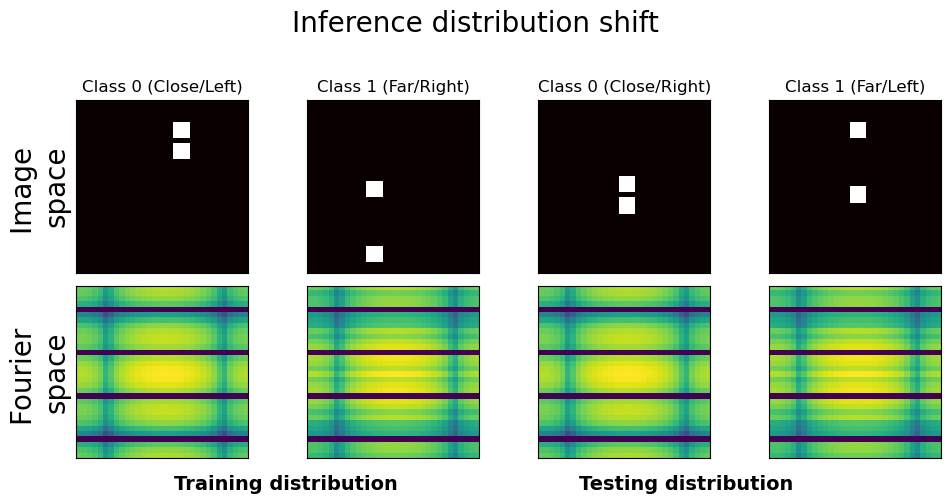

In [2]:
plot_obj_detect(VOL_SIZE)